In [25]:
import subprocess, sys

# Pin xgboost<2 to avoid base_score JSON format breaking SHAP
pkgs = [
    "numpy<2",
    "xgboost<2",
    "shap",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "scipy",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Done. RESTART THE KERNEL, then Run All.")

Done. RESTART THE KERNEL, then Run All.


In [26]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap

print("All imports OK")

All imports OK


In [27]:
rng = np.random.default_rng(42)

counties = ["Nairobi", "Nakuru", "Kisumu", "Uasin Gishu"]
years = list(range(2013, 2024))

rows = []
for county in counties:
    base_rain = rng.uniform(55, 90)
    for year in years:
        rain = base_rain + rng.normal(0, 12)
        rows.append(
            dict(
                county=county,
                year=year,
                rainfall_mm=rain,
                rainfall_anomaly=rain - base_rain,
                temp_max_c=rng.uniform(28, 34),
                temp_min_c=rng.uniform(13, 18),
                soil_organic_carbon=rng.uniform(0.8, 3.5),
                road_density_km_per_km2=rng.uniform(0.4, 2.5),
                population_density=rng.uniform(1000, 8000),
                ndvi_mean=rng.uniform(0.2, 0.6),
            )
        )

df = pd.DataFrame(rows)

df["risk_index"] = (
    df["rainfall_anomaly"].abs() / (df["rainfall_mm"] + 1e-9)
    + (1 - df["soil_organic_carbon"] / 10)
    + (1 - df["road_density_km_per_km2"] / 5)
)
df["risk_index"] = (df["risk_index"] - df["risk_index"].min()) / (
    df["risk_index"].max() - df["risk_index"].min() + 1e-9
)
df["high_risk"] = (df["risk_index"] > df["risk_index"].quantile(0.66)).astype(int)

print(df.shape)
print(df["high_risk"].value_counts().to_dict())
df.head()

(44, 12)
{0: 29, 1: 15}


,county,year,rainfall_mm,rainfall_anomaly,temp_max_c,temp_min_c,soil_organic_carbon,road_density_km_per_km2,population_density,ndvi_mean,risk_index,high_risk
0,Nairobi,2013,69.608652,-12.479809,33.151588,16.486840,1.054279,2.448807,6327.977914,0.514426,0.321649,0
1,Nairobi,2014,81.886848,-0.201614,30.702316,14.853990,3.302265,1.752117,6759.331293,0.377366,0.054891,0
2,Nairobi,2015,71.776952,-10.311510,31.327509,13.319086,3.034604,1.726495,6306.614181,0.341810,0.230932,0
3,Nairobi,2016,96.758958,14.670496,33.358727,16.891917,1.325525,1.380114,1306.626361,0.261716,0.483308,1
4,Nairobi,2017,87.258314,5.169852,32.468573,17.837549,1.679728,1.177965,4286.890679,0.275789,0.394455,0


In [28]:
FEATURE_COLS = [
    "rainfall_mm",
    "rainfall_anomaly",
    "temp_max_c",
    "temp_min_c",
    "soil_organic_carbon",
    "road_density_km_per_km2",
    "population_density",
    "ndvi_mean",
]
X = df[FEATURE_COLS]
y = df["high_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (35, 8)   Test: (9, 8)


In [29]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print("Training complete")

[0]	validation_0-logloss:0.67382


[50]	validation_0-logloss:0.52283
[100]	validation_0-logloss:0.61498
[150]	validation_0-logloss:0.67916
[199]	validation_0-logloss:0.74835
Training complete


              precision    recall  f1-score   support

    low_risk       0.75      1.00      0.86         6
   high_risk       1.00      0.33      0.50         3

    accuracy                           0.78         9
   macro avg       0.88      0.67      0.68         9
weighted avg       0.83      0.78      0.74         9

ROC-AUC: 0.7778


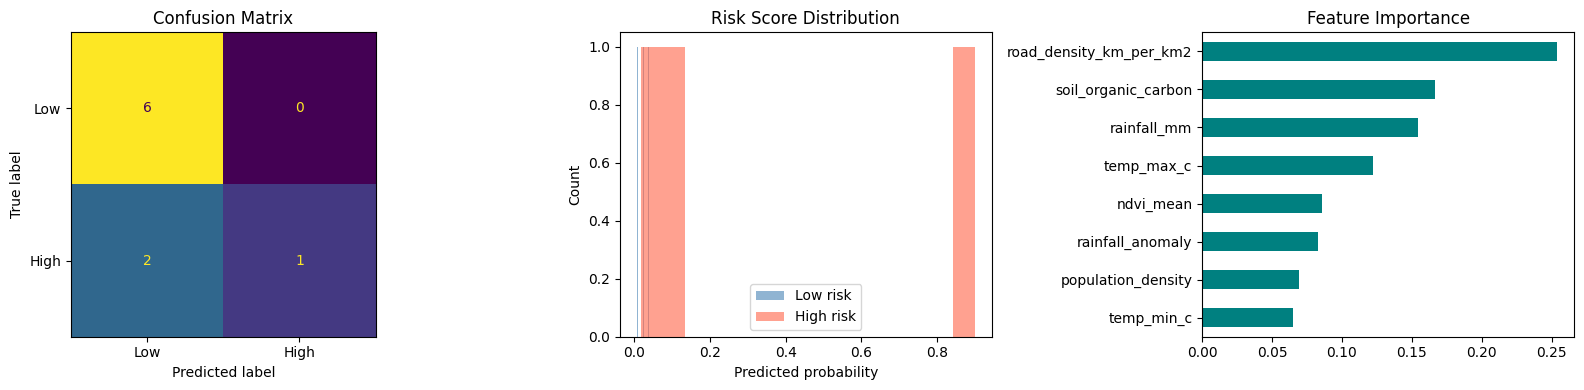

In [30]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["low_risk", "high_risk"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Low", "High"], colorbar=False, ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

axes[1].hist(
    y_prob[y_test == 0], bins=15, alpha=0.6, label="Low risk", color="steelblue"
)
axes[1].hist(y_prob[y_test == 1], bins=15, alpha=0.6, label="High risk", color="tomato")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Risk Score Distribution")
axes[1].legend()

feat_imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
feat_imp.plot(kind="barh", ax=axes[2], color="teal")
axes[2].set_title("Feature Importance")

plt.tight_layout()
plt.show()

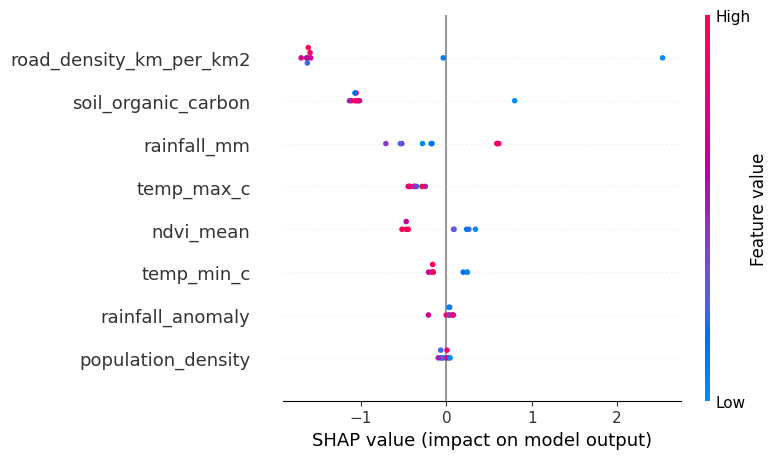

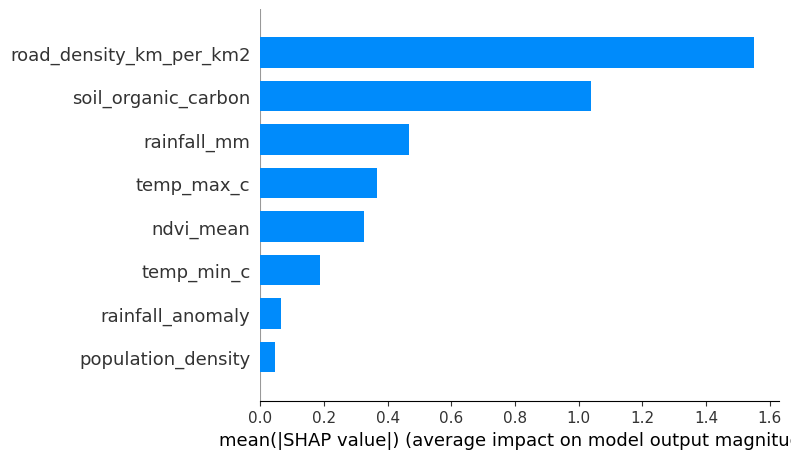

In [31]:
# SHAP explainability (xgboost<2 pinned in Cell 1 -- no base_score issues)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Beeswarm dot plot coloured by feature value
shap.summary_plot(
    shap_values, X_test, feature_names=FEATURE_COLS, plot_type="dot", show=True
)

# Mean |SHAP| bar chart
shap.summary_plot(
    shap_values, X_test, feature_names=FEATURE_COLS, plot_type="bar", show=True
)

Pearson r: 0.2100   Peak forecast year: 2037


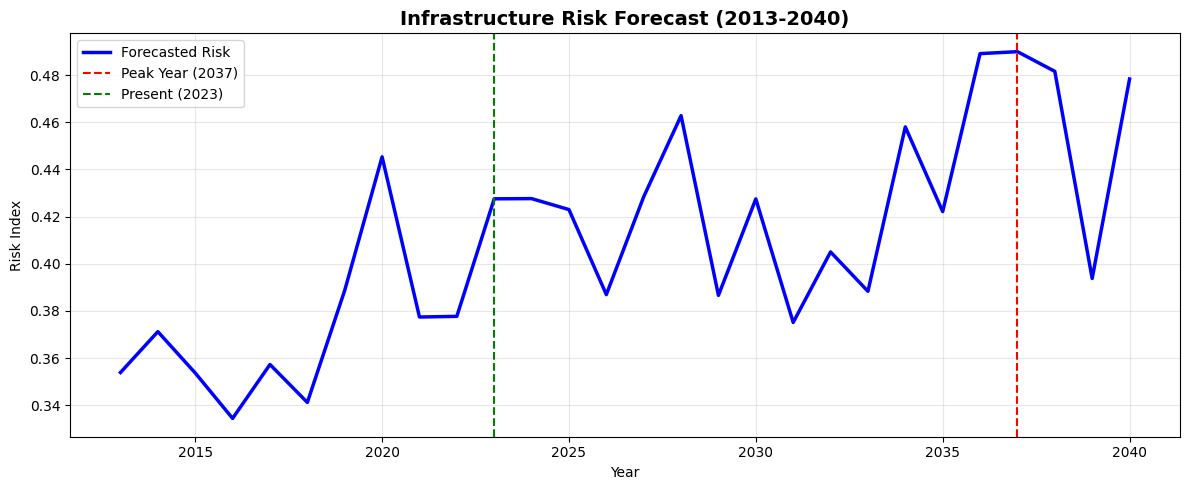

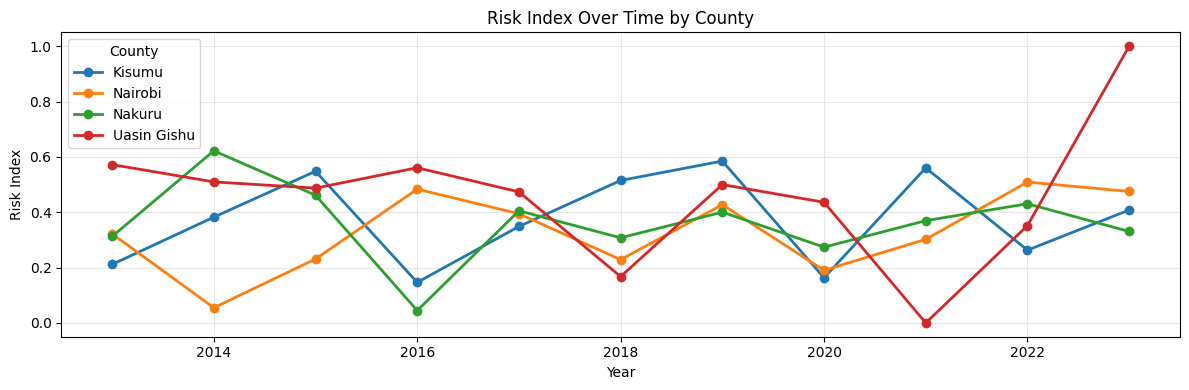

Risk probability: 0.0452  ->  LOW RISK


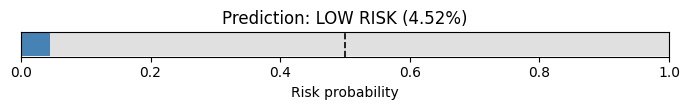

In [32]:
from scipy.stats import pearsonr

# --- Infrastructure Risk Forecast 2013-2040 ---
annual_risk = df.groupby("year")["risk_index"].mean()
years_hist = annual_risk.index.values
risk_hist = annual_risk.values

coeffs = np.polyfit(years_hist, risk_hist, 1)
trend_fn = np.poly1d(coeffs)
rng2 = np.random.default_rng(7)
forecast_years = np.arange(2013, 2041)
forecast_risk = np.clip(
    [trend_fn(y) + rng2.normal(0, 0.04) for y in forecast_years], 0, 1
)
peak_year = forecast_years[np.argmax(forecast_risk)]
pearson_r, _ = pearsonr(years_hist, risk_hist)
print(f"Pearson r: {pearson_r:.4f}   Peak forecast year: {peak_year}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    forecast_years, forecast_risk, color="blue", linewidth=2.5, label="Forecasted Risk"
)
ax.axvline(
    peak_year,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Peak Year ({peak_year})",
)
ax.axvline(2023, color="green", linestyle="--", linewidth=1.5, label="Present (2023)")
ax.set_title("Infrastructure Risk Forecast (2013-2040)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Risk Index")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Per-county risk trend ---
fig2, ax2 = plt.subplots(figsize=(12, 4))
pivot = df.pivot_table(index="year", columns="county", values="risk_index")
pivot.plot(ax=ax2, marker="o", linewidth=2)
ax2.set_title("Risk Index Over Time by County")
ax2.set_xlabel("Year")
ax2.set_ylabel("Risk Index")
ax2.legend(title="County")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Sample prediction gauge ---
new_sample = pd.DataFrame(
    [
        {
            "rainfall_mm": 73.0,
            "rainfall_anomaly": 5.0,
            "temp_max_c": 31.0,
            "temp_min_c": 15.0,
            "soil_organic_carbon": 1.6,
            "road_density_km_per_km2": 1.2,
            "population_density": 4800.0,
            "ndvi_mean": 0.37,
        }
    ]
)
risk_prob = model.predict_proba(new_sample)[0, 1]
risk_label = "HIGH" if risk_prob >= 0.5 else "LOW"
print(f"Risk probability: {risk_prob:.4f}  ->  {risk_label} RISK")

fig3, ax3 = plt.subplots(figsize=(7, 1.2))
ax3.barh(0, risk_prob, color="tomato" if risk_prob >= 0.5 else "steelblue", height=0.5)
ax3.barh(0, 1 - risk_prob, left=risk_prob, color="#e0e0e0", height=0.5)
ax3.axvline(0.5, color="black", linewidth=1.2, linestyle="--")
ax3.set_xlim(0, 1)
ax3.set_yticks([])
ax3.set_xlabel("Risk probability")
ax3.set_title(f"Prediction: {risk_label} RISK ({risk_prob:.2%})")
plt.tight_layout()
plt.show()


--- Scenario 1: Kisumu (dry year, poor infrastructure) ---
  CLIMATE RESILIENCE RISK ASSESSMENT
  Rainfall (mm)                48.0
  Rainfall anomaly (mm)        -18.0
  Temp max (°C)                33.5
  Temp min (°C)                17.0
  Soil organic carbon          1.1
  Road density (km/km²)        0.5
  Population density           6200
  NDVI mean                    0.22
------------------------------------------------
  Risk probability:            93.88%
  Risk label:                  HIGH RISK
  Risk tier:                   Critical (>80%)


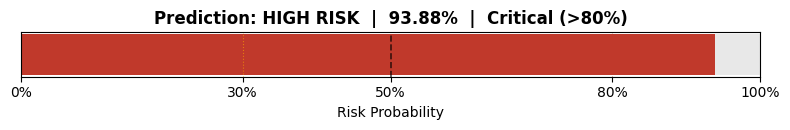


--- Scenario 2: Nakuru (average conditions) ---
  CLIMATE RESILIENCE RISK ASSESSMENT
  Rainfall (mm)                73.0
  Rainfall anomaly (mm)        5.0
  Temp max (°C)                31.0
  Temp min (°C)                15.0
  Soil organic carbon          1.6
  Road density (km/km²)        1.2
  Population density           4800
  NDVI mean                    0.37
------------------------------------------------
  Risk probability:            4.52%
  Risk label:                  LOW RISK
  Risk tier:                   Low (<30%)


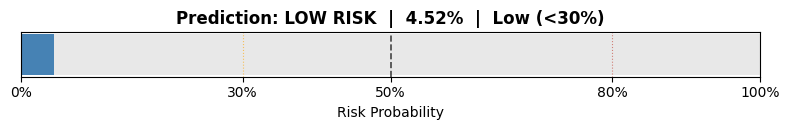


--- Scenario 3: Uasin Gishu (good conditions, low risk) ---
  CLIMATE RESILIENCE RISK ASSESSMENT
  Rainfall (mm)                88.0
  Rainfall anomaly (mm)        2.0
  Temp max (°C)                28.5
  Temp min (°C)                14.0
  Soil organic carbon          3.1
  Road density (km/km²)        2.2
  Population density           1800
  NDVI mean                    0.55
------------------------------------------------
  Risk probability:            2.57%
  Risk label:                  LOW RISK
  Risk tier:                   Low (<30%)


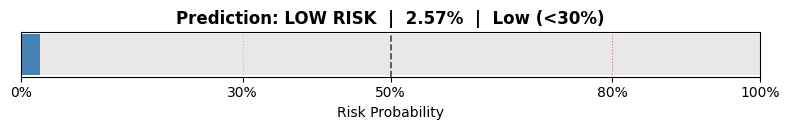

{'risk_probability': 0.025714991614222527,
 'risk_label': 'LOW',
 'risk_tier': 'Low (<30%)'}

In [33]:
def predict_risk(
    rainfall_mm,
    rainfall_anomaly,
    temp_max_c,
    temp_min_c,
    soil_organic_carbon,
    road_density_km_per_km2,
    population_density,
    ndvi_mean,
):
    """
    Predict climate resilience risk for a county observation.

    Returns
    -------
    dict with keys: risk_probability, risk_label, risk_tier
    and prints a formatted summary with a probability gauge.
    """
    sample = pd.DataFrame(
        [
            {
                "rainfall_mm": rainfall_mm,
                "rainfall_anomaly": rainfall_anomaly,
                "temp_max_c": temp_max_c,
                "temp_min_c": temp_min_c,
                "soil_organic_carbon": soil_organic_carbon,
                "road_density_km_per_km2": road_density_km_per_km2,
                "population_density": population_density,
                "ndvi_mean": ndvi_mean,
            }
        ]
    )

    prob = float(model.predict_proba(sample)[0, 1])
    label = "HIGH" if prob >= 0.5 else "LOW"
    tier = (
        "Critical (>80%)"
        if prob >= 0.8
        else (
            "High (50–80%)"
            if prob >= 0.5
            else "Moderate (30–50%)" if prob >= 0.3 else "Low (<30%)"
        )
    )

    # --- Printed summary ---
    print("=" * 48)
    print(f"  CLIMATE RESILIENCE RISK ASSESSMENT")
    print("=" * 48)
    inputs = {
        "Rainfall (mm)": rainfall_mm,
        "Rainfall anomaly (mm)": rainfall_anomaly,
        "Temp max (°C)": temp_max_c,
        "Temp min (°C)": temp_min_c,
        "Soil organic carbon": soil_organic_carbon,
        "Road density (km/km²)": road_density_km_per_km2,
        "Population density": population_density,
        "NDVI mean": ndvi_mean,
    }
    for k, v in inputs.items():
        print(f"  {k:<28} {v}")
    print("-" * 48)
    print(f"  Risk probability:            {prob:.2%}")
    print(f"  Risk label:                  {label} RISK")
    print(f"  Risk tier:                   {tier}")
    print("=" * 48)

    # --- Gauge chart ---
    colors = {
        "Critical (>80%)": "#c0392b",
        "High (50–80%)": "tomato",
        "Moderate (30–50%)": "orange",
        "Low (<30%)": "steelblue",
    }
    bar_color = colors[tier]

    fig, ax = plt.subplots(figsize=(8, 1.4))
    ax.barh(0, prob, color=bar_color, height=0.5)
    ax.barh(0, 1 - prob, left=prob, color="#e8e8e8", height=0.5)
    ax.axvline(0.5, color="black", linewidth=1.2, linestyle="--", alpha=0.7)
    for threshold, color in [(0.3, "orange"), (0.8, "#c0392b")]:
        ax.axvline(threshold, color=color, linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.3, 0.5, 0.8, 1.0])
    ax.set_xticklabels(["0%", "30%", "50%", "80%", "100%"])
    ax.set_yticks([])
    ax.set_xlabel("Risk Probability")
    ax.set_title(
        f"Prediction: {label} RISK  |  {prob:.2%}  |  {tier}", fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    return {"risk_probability": prob, "risk_label": label, "risk_tier": tier}


# --- Example predictions ---

print("\n--- Scenario 1: Kisumu (dry year, poor infrastructure) ---")
predict_risk(
    rainfall_mm=48.0,
    rainfall_anomaly=-18.0,
    temp_max_c=33.5,
    temp_min_c=17.0,
    soil_organic_carbon=1.1,
    road_density_km_per_km2=0.5,
    population_density=6200,
    ndvi_mean=0.22,
)

print("\n--- Scenario 2: Nakuru (average conditions) ---")
predict_risk(
    rainfall_mm=73.0,
    rainfall_anomaly=5.0,
    temp_max_c=31.0,
    temp_min_c=15.0,
    soil_organic_carbon=1.6,
    road_density_km_per_km2=1.2,
    population_density=4800,
    ndvi_mean=0.37,
)

print("\n--- Scenario 3: Uasin Gishu (good conditions, low risk) ---")
predict_risk(
    rainfall_mm=88.0,
    rainfall_anomaly=2.0,
    temp_max_c=28.5,
    temp_min_c=14.0,
    soil_organic_carbon=3.1,
    road_density_km_per_km2=2.2,
    population_density=1800,
    ndvi_mean=0.55,
)